Colab to reproduce results from the WMT23 metrics shared task

## Dependencies

In [80]:

# @title Install MTME

!git clone https://github.com/google-research/mt-metrics-eval.git && cd mt-metrics-eval && pip install .

fatal: destination path 'mt-metrics-eval' already exists and is not an empty directory.


In [1]:
# @title Imports
from mt_metrics_eval import meta_info
from mt_metrics_eval import data
from mt_metrics_eval import tasks

In [2]:
# @title Download data

data.Download()  # Copies about 2G onto local machine.

### Load Scores of new Metric

In [3]:
def load_new_metric(metrics=["smatch"], parser="large"):
    """metric: 'smatch', 'sembleu', and 'amrsim'...."""
    if type(metrics) is not list:
        metrics = [metrics]
    # load existing metric data 
    zh2en = data.EvalSet("wmt23", "zh-en", True)
    he2en = data.EvalSet("wmt23", "he-en", True)
    # now add and load new metric data
    all_pri_metrics = set()
    for metric in metrics:
        metric = metric.lower()
        pri_metric_name = "AMR"
        if metric == "smatch":
            pri_metric_name = "AMR_sm"
        elif metric == "sembleu":
            pri_metric_name = "AMR_bleu"
        elif metric == "amrsim":
            pri_metric_name = "AMR_sim"
        elif metric == "smatch++":
            pri_metric_name = "AMR_sm++"    
        all_pri_metrics.add(pri_metric_name)
           
        zh2en.AddMetricsFromDir(f"amr_metrics/{metric}_scores/ibm_{parser}/{metric}_zh-en", replace=True)
        he2en.AddMetricsFromDir(f"amr_metrics/{metric}_scores/ibm_{parser}/{metric}_he-en", replace=True)
        
        print(zh2en.Scores("sys", f"{pri_metric_name}-refA"))
        print(he2en.Scores("sys", f"{pri_metric_name}-refB"))
    
    zh2en.SetPrimaryMetrics(zh2en.primary_metrics | all_pri_metrics)
    he2en.SetPrimaryMetrics(he2en.primary_metrics | all_pri_metrics)    
    eval_set_dict23 = {("wmt23", "zh-en"):zh2en, ("wmt23", "he-en"):he2en}
    print(he2en.metric_basenames)
    return eval_set_dict23

In [28]:
all_metrics = ["smatch","amrsim", "sembleu", "smatch++"]
eval_set_dict23 = load_new_metric(all_metrics, parser="ensemble")

defaultdict(<class 'list'>, {'ANVITA': [0.314], 'GPT4-5shot': [0.339], 'HW-TSC': [0.374], 'IOL_Research': [0.342], 'Lan-BridgeMT': [0.342], 'NLLB_Greedy': [0.307], 'NLLB_MBR_BLEU': [0.303], 'ONLINE-A': [0.345], 'ONLINE-B': [0.373], 'ONLINE-G': [0.338], 'ONLINE-M': [0.32], 'ONLINE-W': [0.334], 'ONLINE-Y': [0.333], 'refA': [1.0], 'synthetic_ref': [0.626], 'Yishu': [0.372], 'ZengHuiMT': [0.34]})
defaultdict(<class 'list'>, {'GPT4-5shot': [0.778], 'GTCOM_Peter': [0.747], 'Lan-BridgeMT': [0.699], 'NLLB_Greedy': [0.704], 'NLLB_MBR_BLEU': [0.696], 'ONLINE-A': [0.754], 'ONLINE-B': [0.757], 'ONLINE-G': [0.735], 'ONLINE-Y': [0.724], 'refA': [0.735], 'refB': [1.0], 'Samsung_Research_Philippines': [0.668], 'UvA-LTL': [0.735], 'ZengHuiMT': [0.741]})
defaultdict(<class 'list'>, {'ONLINE-G': [0.8602206342459515], 'NLLB_Greedy': [0.8145635248076923], 'ONLINE-Y': [0.8553514800151822], 'ONLINE-B': [0.8777996989625506], 'ONLINE-W': [0.8481558138765182], 'ONLINE-A': [0.8586949310374494], 'Yishu': [0.87753

#### Reproduce official results

In [29]:
# @title Generate main results

# Generate main results for primary metrics.

# Setting k=0 suppresses significance testing. Results in the paper were
# generated with k=1000, which is too slow to run sequentially in a colab.
main_tasks, main_task_weights = tasks.WMT23(lps=["he-en", "zh-en"], k=0)

# Task names show attributes that define each task.
for i, task in enumerate(main_tasks):
  # # If this way, all other metrics ranks will change as well,
  # # as now all other metrics are using syn-ref for zh-en.
  # # This is found to make AMR rank worse.
  # if task.lang == "zh-en":
  #   task.refs = set(["synthetic_ref"])
  print(f'task{i + 1}: {task.name}')

# Takes about 3 minutes.
main_results = main_tasks.Run(eval_set_dict=eval_set_dict23)

task1: test_set=wmt23 lang=he-en,zh-en domain=None level=sys human=True avg_by=none corr_fcn=accuracy k=0 gold=['mqm','mqm'] refs=[{'refB'},{'refA'}] close_refs=[set(),set()] use_outliers=False primary=True pval=0.05 block_size=100 early_min=0.02 early_max=0.5 replace_nans_with_zeros=False perm_test=scores corr_fcn_args={}
task2: test_set=wmt23 lang=he-en domain=None level=sys human=True avg_by=none corr_fcn=pearson k=0 gold=mqm refs={'refB'} close_refs=set() use_outliers=False primary=True pval=0.05 block_size=100 early_min=0.02 early_max=0.5 replace_nans_with_zeros=False perm_test=scores corr_fcn_args={}
task3: test_set=wmt23 lang=he-en domain=None level=seg human=True avg_by=none corr_fcn=pearson k=0 gold=mqm refs={'refB'} close_refs=set() use_outliers=False primary=True pval=0.05 block_size=100 early_min=0.02 early_max=0.5 replace_nans_with_zeros=False perm_test=scores corr_fcn_args={}
task4: test_set=wmt23 lang=he-en domain=None level=seg human=True avg_by=item corr_fcn=KendallWit

In [30]:
main_task_weights

[0.25, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]

In [31]:
# @title Display main results

# This reproduces Tables 8 and 9 from the shared task paper, modulo signficance
# results.

# AverageCorrMatrix produces significance clusters and pairwise p-values for the
# overall average correlation, but requires that the tasks be run with k > 0.
# AverageCorrs computes the same averages as AverageCorrMatrix but without
# significance.
avg_corrs = main_results.AverageCorrs(main_task_weights)
# avg_corrs, matrix = main_results.AverageCorrMatrix(main_task_weights)

# Use fmt='tsv' to generate tsv format for spreadsheets. This function has
# many other options to customize output.
table = main_results.Table(
    metrics=list(avg_corrs),
    initial_column=avg_corrs,
    initial_column_header='avg-corr',
    attr_list=['lang', 'level', 'corr_fcn'],
    nicknames={'KendallWithTiesOpt': 'acc-t'},
    fmt='latex',
    baselines_metainfo=meta_info.WMT23)

import os
#os.makedirs("results", exist_ok=True)
with open(os.path.join("/pfs/work9/workspace/scratch/tu_zxonr13-space4Tone/amr/mt-metrics-eval/results", "wmt23_all_ensemble_k=0.txt"), "w", encoding="utf-8") as f2:
  f2.write(table)
print(table)


\begin{tabular}{l|rr|rr|rr|rr|rr|rr|rr|rr}
\toprule
lang: & \multicolumn{2}{|l}{} & \multicolumn{2}{|l}{he-en,zh-en} & \multicolumn{2}{|l}{he-en} & \multicolumn{2}{|l}{he-en} & \multicolumn{2}{|l}{he-en} & \multicolumn{2}{|l}{zh-en} & \multicolumn{2}{|l}{zh-en} & \multicolumn{2}{|l}{zh-en} \\
level: & \multicolumn{2}{|l}{} & \multicolumn{2}{|l}{sys} & \multicolumn{2}{|l}{sys} & \multicolumn{2}{|l}{seg} & \multicolumn{2}{|l}{seg} & \multicolumn{2}{|l}{sys} & \multicolumn{2}{|l}{seg} & \multicolumn{2}{|l}{seg} \\
corr\_fcn: & \multicolumn{2}{|l}{} & \multicolumn{2}{|l}{accuracy} & \multicolumn{2}{|l}{pearson} & \multicolumn{2}{|l}{pearson} & \multicolumn{2}{|l}{acc-t} & \multicolumn{2}{|l}{pearson} & \multicolumn{2}{|l}{pearson} & \multicolumn{2}{|l}{acc-t} \\
metric & \multicolumn{2}{|l}{avg-corr} & \multicolumn{2}{|l}{task1} & \multicolumn{2}{|l}{task2} & \multicolumn{2}{|l}{task3} & \multicolumn{2}{|l}{task4} & \multicolumn{2}{|l}{task5} & \multicolumn{2}{|l}{task6} & \multicolumn{2}{

### Plot the results

In [38]:
#%cd ..
%ls

 amr_metrics/            pce.py                  tasks_test.py
 codalab/                pce_test.py             tau_optimization.py
 converters/             __pycache__/            tau_optimization_test.py
 data.py                 ratings.py              ties_matter.ipynb
 data_test.py            ratings_test.py         wmt22_metrics.ipynb
 __init__.py             score_plots/           'wmt23_metrics _amr.ipynb'
 meta_info.py            standalone_ratings.py   wmt23_metrics.ipynb
 mtme.py                 stats.py                wmt23_metrics.py
 mt-metrics-eval/        stats_test.py
 mt_metrics_eval.ipynb   tasks.py


In [39]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
import os

In [40]:
def to_df(input_dir, metric="smatch", parser="large"):
    langs = ["zh-en", "he-en"]
    results = {}
    for lang in langs:
        path = f"{input_dir}/{metric.lower()}_scores/ibm_{parser}/{metric.lower()}_{lang}"
        print(path)
        lang_dfs = {}
        for filename in os.listdir(path):
            with open(os.path.join(path, filename), "r", encoding="utf-8") as f:
                dict = {}
                for line in f:
                    sys, smch = line.split()[0], float(line.split()[-1])
                    if sys == "Samsung_Research_Philippines":
                        sys = 'Samsung_Ph'
                    if "sys" in filename:
                        dict[sys]=smch
                    elif "seg" in filename:
                        if sys not in dict:
                            dict[sys] = [smch]
                        else:
                            dict[sys].append(smch)
                if "sys" in filename:
                    dict["avg"] = np.mean(list(dict.values()))
                    df = pd.DataFrame.from_dict(dict, orient="index", columns=[f"{metric.lower()}_score"])
                    df["lang_pair"] = "→".join(lang.split("-"))
                    df["parser"] = parser
                elif "seg" in filename:
                    df = pd.DataFrame.from_dict(dict, orient="columns")
                
                if "sys" in filename:
                    lang_dfs["sys"] = df
                elif "seg" in filename:
                    lang_dfs["seg"] = df
        results[lang] = lang_dfs
    return results


In [41]:
input_dir = "amr_metrics"
sm_large_dfs = to_df(input_dir)
sm_ensemble_dfs = to_df(input_dir, parser="ensemble")
bleu_large_dfs = to_df(input_dir, metric="sembleu", parser="large")
bleu_ensemble_dfs = to_df(input_dir, metric="sembleu", parser="ensemble")
amrsim_large_dfs = to_df(input_dir, metric="amrsim", parser="large")
amrsim_ensemble_dfs = to_df(input_dir, metric="amrsim", parser="ensemble")
smplus_large_dfs = to_df(input_dir, metric="smatch++", parser="large")
smplus_ensemble_dfs = to_df(input_dir, metric="smatch++", parser="ensemble")
bleu_large_dfs["zh-en"]["sys"], smplus_ensemble_dfs["zh-en"]["sys"]

amr_metrics/smatch_scores/ibm_large/smatch_zh-en
amr_metrics/smatch_scores/ibm_large/smatch_he-en
amr_metrics/smatch_scores/ibm_ensemble/smatch_zh-en
amr_metrics/smatch_scores/ibm_ensemble/smatch_he-en
amr_metrics/sembleu_scores/ibm_large/sembleu_zh-en
amr_metrics/sembleu_scores/ibm_large/sembleu_he-en
amr_metrics/sembleu_scores/ibm_ensemble/sembleu_zh-en
amr_metrics/sembleu_scores/ibm_ensemble/sembleu_he-en
amr_metrics/amrsim_scores/ibm_large/amrsim_zh-en
amr_metrics/amrsim_scores/ibm_large/amrsim_he-en
amr_metrics/amrsim_scores/ibm_ensemble/amrsim_zh-en
amr_metrics/amrsim_scores/ibm_ensemble/amrsim_he-en
amr_metrics/smatch++_scores/ibm_large/smatch++_zh-en
amr_metrics/smatch++_scores/ibm_large/smatch++_he-en
amr_metrics/smatch++_scores/ibm_ensemble/smatch++_zh-en
amr_metrics/smatch++_scores/ibm_ensemble/smatch++_he-en


(               sembleu_score lang_pair parser
 Lan-BridgeMT        0.278562     zh→en  large
 synthetic_ref       0.643809     zh→en  large
 ONLINE-Y            0.279943     zh→en  large
 NLLB_Greedy         0.226850     zh→en  large
 ONLINE-W            0.279653     zh→en  large
 HW-TSC              0.396517     zh→en  large
 ONLINE-M            0.249051     zh→en  large
 ONLINE-G            0.290128     zh→en  large
 ONLINE-B            0.398125     zh→en  large
 ONLINE-A            0.284017     zh→en  large
 NLLB_MBR_BLEU       0.220607     zh→en  large
 IOL_Research        0.275787     zh→en  large
 Yishu               0.396811     zh→en  large
 GPT4-5shot          0.277117     zh→en  large
 ZengHuiMT           0.297203     zh→en  large
 ANVITA              0.233861     zh→en  large
 refA                1.000000     zh→en  large
 avg                 0.354591     zh→en  large,
                smatch++_score lang_pair    parser
 IOL_Research         0.386253     zh→en  ensemble
 ONL

In [42]:
sm_large_dfs["zh-en"]["sys"]

,smatch_score,lang_pair,parser
ANVITA,0.487000,zh→en,large
GPT4-5shot,0.525000,zh→en,large
HW-TSC,0.621000,zh→en,large
IOL_Research,0.520000,zh→en,large
Lan-BridgeMT,0.524000,zh→en,large
NLLB_Greedy,0.482000,zh→en,large
NLLB_MBR_BLEU,0.479000,zh→en,large
ONLINE-A,0.531000,zh→en,large
ONLINE-B,0.621000,zh→en,large
ONLINE-G,0.534000,zh→en,large


In [43]:
# make the x axis the same order
zh_order = ['ANVITA', 'GPT4-5shot', 'HW-TSC', 'IOL_Research', 'Lan-BridgeMT', 'NLLB_Greedy', 'NLLB_MBR_BLEU', 'ONLINE-A', 'ONLINE-B', 'ONLINE-G', 'ONLINE-M', 'ONLINE-W', 'ONLINE-Y', 'Yishu', 'ZengHuiMT', 'synthetic_ref', 'refA', 'avg']
he_order = ['GPT4-5shot', 'GTCOM_Peter', 'Lan-BridgeMT', 'NLLB_Greedy', 'NLLB_MBR_BLEU', 'ONLINE-A', 'ONLINE-B', 'ONLINE-G', 'ONLINE-Y', 'Samsung_Ph', 'UvA-LTL', 'ZengHuiMT', 'refA', 'refB', 'avg']
def plot(metric, metric_large_dfs, metric_ensemble_dfs):
    # concate data
    dfs = [metric_large_dfs["zh-en"]["sys"], metric_large_dfs["he-en"]["sys"], metric_ensemble_dfs["zh-en"]['sys'], metric_ensemble_dfs["he-en"]["sys"]]
    concated_df = pd.concat(dfs, axis=0)
    concated_df = concated_df.reset_index().rename(columns={"index": "system"})
    
    # sort order
    concated_df["order"] = concated_df.apply(
    lambda row: (
        he_order.index(row["system"])
        if row["lang_pair"] == "he→en"
        else zh_order.index(row["system"])
        ),
        axis=1
    )

    concated_df = concated_df.sort_values(["lang_pair", "order"])
    
    # plot
    fig = plt.figure(figsize=(14, 6))
    g = sb.catplot(
        data=concated_df,
        x="system",
        y=f"{metric}_score",
        hue="parser",
        col="lang_pair",
        kind="bar",
        height=4,
        aspect=1.2,
        sharex=False
    )
    g.set_xticklabels(rotation=80)
    g.fig.suptitle(f"{metric.capitalize()} Scores between System Translations and Human References")
    g.tight_layout()
    #g.fig.subplots_adjust(top=0.88)
    g.savefig(f"score_plots/system_level_{metric}_plot")

    return concated_df

,system,amrsim_score,lang_pair,parser,order
20,GPT4-5shot,0.876966,he→en,large,0
53,GPT4-5shot,0.900177,he→en,ensemble,0
18,GTCOM_Peter,0.864564,he→en,large,1
55,GTCOM_Peter,0.888054,he→en,ensemble,1
19,Lan-BridgeMT,0.817107,he→en,large,2
...,...,...,...,...,...
44,synthetic_ref,0.924279,zh→en,ensemble,15
15,refA,1.000000,zh→en,large,16
47,refA,1.000000,zh→en,ensemble,16
17,avg,0.843772,zh→en,large,17


<Figure size 1400x600 with 0 Axes>

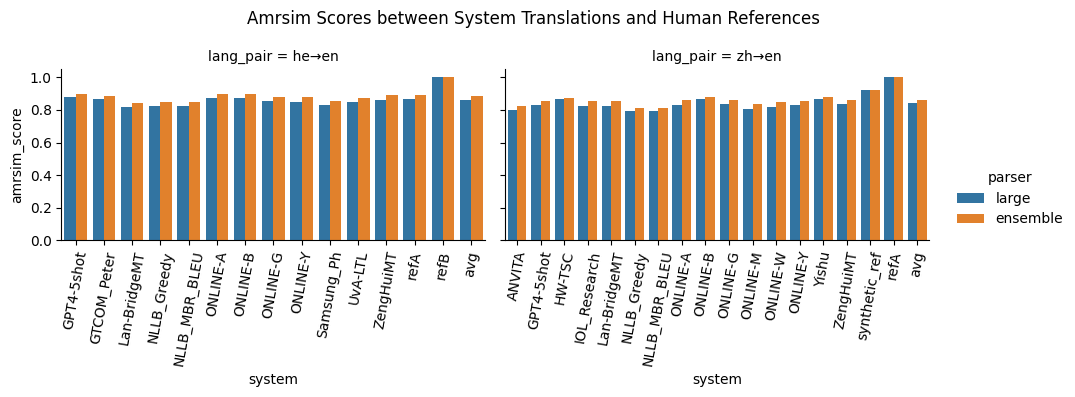

In [46]:
plot("amrsim", amrsim_large_dfs, amrsim_ensemble_dfs)